In [1050]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

## Problem 1 {-}
Consider a constant matrix and a vector function given by
$$
A = \begin{bmatrix} 1 & 2 \\ 2 & -2 \end{bmatrix}, \qquad f(t) = \begin{bmatrix} 2 \\ 3t^{2} \end{bmatrix}
$$

### 1. {-}
Compute $e^{At}$.

To compute the value, the eigenvalues and vectors must first be found. This is done using the sympy python library.

In [1051]:
A = sp.Matrix([[1,2],[2,-2]])
r = A.rank()
lam2, lam1 = A.eigenvals()
vec1 = A.eigenvects()[0][2][0]
vec2 = A.eigenvects()[1][2][0]
print(f"One of the eigenvalues is {lam1}, which has the corresponding eigenvector")
vec1

One of the eigenvalues is -3, which has the corresponding eigenvector


Matrix([
[-1/2],
[   1]])

In [1052]:
print(f"The other eigenvalue is {lam2}, and has the corresponding eigenvector")
vec2

The other eigenvalue is 2, and has the corresponding eigenvector


Matrix([
[2],
[1]])

These can be used to find the eigenvalue solutions of $x' = Ax$ as described in theorem 5.2.1.

In [1053]:
t = sp.Symbol("t")
x1 = sp.exp(lam1*t) * vec1
x2 = sp.exp(lam2*t) * vec2

print(f"The solution for the eigenvalue {lam1} is")
x1

The solution for the eigenvalue -3 is


Matrix([
[-exp(-3*t)/2],
[   exp(-3*t)]])

In [1054]:
print(f"The solution for the eigenvalue {lam2} is")
x2

The solution for the eigenvalue 2 is


Matrix([
[2*exp(2*t)],
[  exp(2*t)]])

These solutions lead to the following fundamental matrix for the equation

In [1055]:
Phi = sp.Matrix([[x1,x2]])
Phi

Matrix([
[-exp(-3*t)/2, 2*exp(2*t)],
[   exp(-3*t),   exp(2*t)]])

The value of $e^{At}$ can finally be computed following theorem 5.6.3, which results in the following

In [1057]:
eAt = Phi * Phi.subs(t,0).inv()
eAt

Matrix([
[  4*exp(2*t)/5 + exp(-3*t)/5, 2*exp(2*t)/5 - 2*exp(-3*t)/5],
[2*exp(2*t)/5 - 2*exp(-3*t)/5,   exp(2*t)/5 + 4*exp(-3*t)/5]])

### 2. {-}
Solve the differential equation $x' = Ax + f(t)$ with initial value $x(0) = [1 \; \; 0]^{T}$ using the variations of parameters approach.

Theorem 5.7.1 can be used as long as $P(t)$ (which in this case is $A$) and $f(t)$ are continuous. Since $A$ is constant and therefore continuous, and $f(t)$ is given as a continuous function of $t$, this theorem can be used. Solving with this approach requires the general solution to the complementary homogeneous equation. This solution can be found using theorem 5.6.2 by combining the value of $e^{At}$ from the previous section with the given initial value. This results in the following solution

In [1058]:
a = 0
xa = sp.Matrix([[1,0]]).T
s = sp.Symbol("s")
f = sp.Matrix([[2, 3*t**2]]).T
xc = Phi * Phi.subs(t, a).inv() * xa
xc

Matrix([
[  4*exp(2*t)/5 + exp(-3*t)/5],
[2*exp(2*t)/5 - 2*exp(-3*t)/5]])

Now a particular solution must be found using the variation of parameters formula. Since any integration constant is sufficient for the particular solution, the particular solution where $x_{p}(a) = 0$ is chosen to get an integration constant of 0. This is true if the integration limits are from $a$ to $a$ at the point $t=a$. The particular solution is then defined using the fundamental matrix as
$$
x_{p}(t) = \Phi(t) \int_{a}^{t} \Phi^{-1}(s) f(s) \, ds
$$
Calculating this with sympy results in

In [1059]:
xp = Phi * sp.integrate(Phi.subs(t, s).inv() * f.subs(t, s), (s, a, t))
xp.simplify()

Matrix([
[   -t**2 - t/3 + 11*exp(2*t)/10 - 19/18 - 2*exp(-3*t)/45],
[t**2/2 - 5*t/6 + 11*exp(2*t)/20 - 23/36 + 4*exp(-3*t)/45]])

The sum of these two solutions must then be the general solution to the initial value problem

In [1060]:
xt = xc + xp
sp.simplify(xt)

Matrix([
[    -t**2 - t/3 + 19*exp(2*t)/10 - 19/18 + 7*exp(-3*t)/45],
[t**2/2 - 5*t/6 + 19*exp(2*t)/20 - 23/36 - 14*exp(-3*t)/45]])

### 3. {-}
Explain how the solution changes if the system is started from a different $x_{0}$. Include a phase plane portrait with (at least) two examples of different $x_{0}$ values.

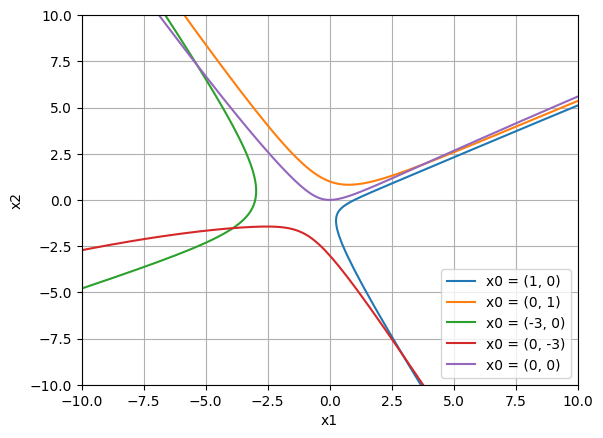

In [1061]:
def sol(x0):
    return eAt * x0 + xp

x0_list = sp.Matrix([   [1,0,-3,0,0],
                        [0,1,0,-3,0],])

time = np.linspace(-5,5,300)

for i in range(x0_list.shape[1]):
    x0 = x0_list[:,i]
    x1 = sp.lambdify(t, sol(x0)[0,:], "numpy")
    x2 = sp.lambdify(t, sol(x0)[1,:], "numpy")

    x1sol = np.ravel(x1(time))
    x2sol = np.ravel(x2(time))

    plt.plot(x1sol, x2sol, label=f"x0 = ({x0[0]}, {x0[1]})")

plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.xlim([-10,10])
plt.ylim([-10,10])
plt.legend()
plt.show()

WRITE SOME DESCRIPTION HERE

## Problem 2 {-}
Consider the constant matrix given by
$$
A = \begin{bmatrix} 1 & 0 & 0 \\ 1 & 3 & 1 \\ -2 & -4 & -1 \end{bmatrix}
$$

### 1. {-}
Compute the eigenvalues and (generalized) eigenvectors of A.

The python sympy library is used to compute the eigenvalue of $A$. The eigenvalue is computed to be

In [1062]:
A = sp.Matrix([[1,0,0], [1,3,1], [-2,-4,-1]])

lam = list(A.eigenvals().keys())[0]
lam

1

Since $A$ has a rank of 3, but only one eigenvalue. The multiplicity of this eigenvalue is 3. To find the eigenvector the equation $(A - \lambda I_{3})v = \vec{0}$ is solved

\begin{align*}
A - \lambda I_{3} &= \begin{bmatrix}
1-1 & 0 & 0 \\
1 & 3-1 & 1 \\
-2 & -4 & -1-1
\end{bmatrix}\\
&= \begin{bmatrix}
0 & 0 & 0 \\
1 & 2 & 1 \\
-2 & -4 & -2
\end{bmatrix}\\
&\sim_{R_{2} \to R_{2} + 2R_{1}}\\
&\begin{bmatrix}
0 & 0 & 0 \\
1 & 2 & 1 \\
0 & 0 & 0
\end{bmatrix}
\end{align*}

Now a solution to the following equation has to be found
$$
x + 2y + z = 0
$$

Since there are 2 free variables and one dependent variable in this case, it is known that the corresponding eigenvectors span a 2-dimensional space. Two independent solutions could be

$$
u_{1} = 
\begin{bmatrix}
-2 \\
1 \\
0
\end{bmatrix}
$$

$$
v_{1} = 
\begin{bmatrix}
0 \\
1 \\
-2
\end{bmatrix}
$$

Any other solution for the eigenvalue would be a linear combination of the two eigenvectors. Since the eigenvalue has a multiplicity of 3 but only 2 eigenvectors, it has a defect of $d=1$, meaning it must be possible to find a length 2 chain of generalized eigenvectors associated with the eigenvalue. The eigenvector $v_{1}$ is chosen to be the ordinary eigenvector of the chain, meaning that last vector must satisfy the equation $(A - \lambda I_{3})v_{2} = v_{1}$. Looking at the matrix
$$
A - \lambda I_{3} = \begin{bmatrix}
0 & 0 & 0 \\
1 & 2 & 1 \\
-2 & -4 & -2
\end{bmatrix}
$$
it can be seen that $v_{1}$ is in the column space of the matrix (column 2 if zero-indexed). This means that the last generalized eigenvector in the chain must be
$$
v_{2} = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}
$$

### 2. {-} 
Find the three solutions, $x_{1}(t)$, $x_{2}(t)$, and $x_{3}(t)$ of $x' = Ax$. Show that the solutions are linearly independent.

The first solution $x_{1}(t)$ can be found with the $u_{1}$ using Theorem 5.2.1. The last two independent solutions are found using the second part of the defective multiplicity 2 eigenvalue algorithm. This can be done even though the eigenvalue had a multiplicity of 3, since it only had a defect of 1, meaning that there was only a chain of length 2, which is what the second part of the algorithm solves for. The three solution are computed using the sympy library

In [1071]:
u1 = sp.Matrix([[-2,1,0]]).T
v1 = sp.Matrix([[0,1,-2]]).T
v2 = sp.Matrix([[0,0,1]]).T

t = sp.symbols("t")

x1 = u1 * sp.exp(lam*t)
x2 =  v1 * sp.exp(lam*t)
x3 = sp.expand((v1*t + v2) * sp.exp(lam*t))

print("The first solution x1(t) is")
display(x1)
print("The second solution x2(t) is")
display(x2)
print("The third solution x3(t) is")
display(x3)

The first solution x1(t) is


Matrix([
[-2*exp(t)],
[   exp(t)],
[        0]])

The second solution x2(t) is


Matrix([
[        0],
[   exp(t)],
[-2*exp(t)]])

The third solution x3(t) is


Matrix([
[                   0],
[            t*exp(t)],
[-2*t*exp(t) + exp(t)]])

To check whether the three solutions are linearly independent, they are combined into a matrix, where each column is one of the three solutions. If the row echelon form of this matrix has a pivot all solutions are linearly independent. The matrix looks as follows

In [1066]:
X = sp.Matrix([[x1,x2,x3]])
X

Matrix([
[-2*exp(t),         0,                    0],
[   exp(t),    exp(t),             t*exp(t)],
[        0, -2*exp(t), -2*t*exp(t) + exp(t)]])

Using matrix row operations the following result is obtained

In [1067]:
X[1,:] += 1/2 * X[0,:]
X[2,:] += 2 * X[1,:]
X

Matrix([
[-2*exp(t),      0,        0],
[        0, exp(t), t*exp(t)],
[        0,      0,   exp(t)]])

Since every row has a pivot, the three solutions must be linearly independent.

### 3. {-} 
Solve the differential equation $x' = Ax$ with initial value $x(0) = [1 \; \; 0 \; \; 0]^{T}$.

Since it is a homogeneous differential equation, the solution will be determined as $x(t) = e^{At} x_{0}$, which is computed the same way as in problem 1.1. The solution is then

In [1068]:
Phi = sp.Matrix([[x1, x2, x3]])
eAt = Phi * Phi.subs(t,0).inv()
x0 = sp.Matrix([[1,0,0]]).T
xt = eAt * x0
xt

Matrix([
[     exp(t)],
[   t*exp(t)],
[-2*t*exp(t)]])

### 4. {-} 
Does the solution to the initial value problem pass through the point $x_{m} = [2 \; \; 2 \; \; 3]^{T}$?

To find out whether the solution passes through the point, the value of $t$ that should return the point is found. When looking at the first coordinate of the solution and point, an equation can be constructed and solved to find the following value of $t$

\begin{align*}
e^{t} &= 2\\
t &= \ln(2)
\end{align*}

Inserting this value of $t$ into the solution gives the following point

In [1069]:
sp.simplify(xt.subs(t,sp.ln(2)))

Matrix([
[       2],
[  log(4)],
[-log(16)]])

Since the result does not match the given point in any other coordinate than the first, the solution does not pass through the point.

## Problem 3 {-}
Consider two second order systems given by

\begin{align*}
x'' + 2x' + 400x &= 0\\
y'' + 3y' + 400y &= 0
\end{align*}

### 1. {-} 
Classify the two systems and account for similarities and differences between them. What happens to the two systems if they are started from rest and unit offset at $t = 0$?

Both systems are described with homogeneous second order differential equations. Since they are homogeneous and of this form, they can both be described as mass spring dashpot systems with no contribution from external forces. The first and last term of the systems are similar, which means that they have the same natural frequency of
$$
\omega_{0} = \sqrt{\frac{400}{1}} = 20
$$

For the same reason they also share the same critical damping value of
$$
c_{cr} = \sqrt{4 \cdot 400 \cdot 1} = 40
$$

Both systems are underdamped, but due to the differences in value, the system $x(t)$ is slightly more underdamped with a damping constant of 2 rather than the system $y(t)$, which has a damping constant of 3. This means that though both systems oscillate and decay toward equilibrium, $y(t)$ will decay at a faster rate than $x(t)$.

If the systems start at rest it means that their rate of change at time $t=0$ is
$$
x'(0) = y'(0) = 0
$$

With an initial offset at $t=0$ the systems would oscillate and decay as described.

### 2. {-}
Next, assume that the two systems are affected by a coupling between them that is proportional to the displacement of each system. The model therefore becomes

\begin{align*}
x'' + 2x' + 400x + \alpha xy &= 0\\
y'' + 3y' + 400y + \alpha xy &= 0
\end{align*}

Due to the coupling, it is now necessary to use numerical methods to solve the differential equations.

Compute the solutions, $x(t)$ and $y(t)$ of the coupled differential equations for the case of $\alpha = 0.1$ where the systems are again started from rest and unit offset at $t = 0$. Plot the solutions and describe any changes to the solutions relative to the non-coupled $\alpha = 0$ case.

### 3. {-}
What happens to the solutions if the first system is not started from unit offset, but at some other offset?

### 4. {-}
Finally, assume that the first system is driven by an external force

\begin{align*}
x'' + 2x' + 400x + \alpha xy &= 0\\
y'' + 3y' + 400y + \alpha xy &= 0
\end{align*}

Again, compute and plot solutions for $x(t)$ and $y(t)$ for the $\alpha = 0.1$ case. Describe the effects of the external force on system 1.

## Problem 4 {-}
Consider the two-population system given by
$$
\frac{dx}{dt} = 30x − 2x^{2} − xy, \qquad \frac{dy}{dt} = 20y − 4y^{2} + 2xy
$$

### 1. {-}
Describe the type of x- and y-populations involved and the nature of their interaction.

Since the last term of the two equations have different signs, the interaction between the two populations is a predation. Seeing as the last term is negative for the $x$-population it must be the prey, meaning that the $y$-population is the predator. In other words the $x$-population is the hurt by the growth of the $y$-population, while the growth of the $x$-population helps the $y$-population. Since the equations have second order terms, it means that both populations will exhibit logistic growth in the absence of the other population.

SKRIV NOGET OM INHIBITION vs COMPETITION

### 2. {-}
Find and characterize the system's critical points with respect to type and stability.

NOTE:

0,5 og 15,0 er saddle points

### 3. {-}
Determine what nonzero x- and y-populations can coexist.

DESCRIBE SOMETHING WITH SEPERATIX like in figure 6.3.8

### 4. {-}
Construct a phase-plane portrait and describe the long-term behaviour of the two populations in terms of their initial populations $x(0)$ and $y(0)$.